<a href="https://colab.research.google.com/github/Sahil-K-Y/AI-ML-Blueprint/blob/main/Phase-6%20-%20Deep%20Learning%20%26%20PyTorch/086_minibatch_gd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np

In [27]:
import pandas as pd

In [28]:
import matplotlib.pyplot as plt


In [29]:
np.random.seed(42)

In [30]:
N=1000

In [31]:
X=2*np.random.rand(N,1)

In [32]:
len(X)

1000

In [33]:
y = 4 + 3 * X + np.random.randn(N, 1) * 0.5

In [34]:
len(y)

1000

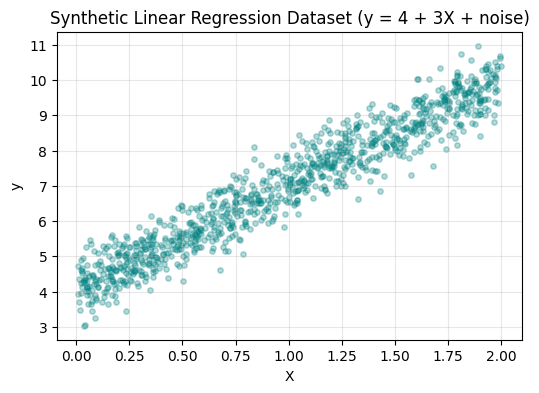

In [35]:

X_b = np.c_[np.ones((N, 1)), X]

# Scatter plot
plt.figure(figsize=(6, 4))
plt.scatter(X, y, alpha=0.3, color="teal", s=15)
plt.title("Synthetic Linear Regression Dataset (y = 4 + 3X + noise)")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
lr=0.1

In [37]:
n_epochs=50

In [38]:
m=len(X_b)

In [39]:
np.random.seed(42)

In [40]:
theta_bgd = np.random.randn(2, 1)

bgd_loss_history = []
theta_bgd_history = [theta_bgd.copy()]

In [41]:
for epoch in range(n_epochs):
  y_pred=X_b.dot(theta_bgd)
  loss=(1/(2*m))*np.sum((y_pred-y)**2)
  bgd_loss_history.append(loss)
  gradients = (1 / m) * X_b.T.dot(y_pred - y)
  theta_bgd=theta_bgd-lr*gradients
  theta_bgd_history.append(theta_bgd.copy())

In [42]:
print(f"BGD Converged Values:")
print(f"  Bias   (Target ~4) : {theta_bgd[0][0]:.4f}")
print(f"  Weight (Target ~3) : {theta_bgd[1][0]:.4f}")
print(f"Final Loss           : {bgd_loss_history[-1]:.4f}")

BGD Converged Values:
  Bias   (Target ~4) : 3.8464
  Weight (Target ~3) : 3.1679
Final Loss           : 0.1301


In [43]:
len(bgd_loss_history)

50

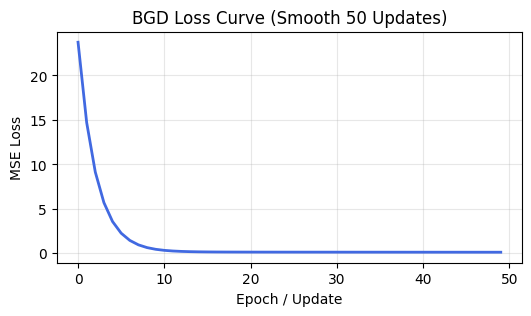

In [44]:
plt.figure(figsize=(6, 3))
plt.plot(bgd_loss_history, color="royalblue", lw=2)
plt.title("BGD Loss Curve (Smooth 50 Updates)")
plt.xlabel("Epoch / Update")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
np.random.seed(42)
theta_sgd = np.random.randn(2, 1)

sgd_loss_history = []
theta_sgd_history = [theta_sgd.copy()]

In [46]:
t0, t1 = 5, 50
def learning_schedule(t):
    return t0 / (t + t1)

In [47]:
for epoch in range(n_epochs):
  epoch_loss = (1 / (2 * m)) * np.sum((X_b.dot(theta_sgd) - y) ** 2)
  sgd_loss_history.append(epoch_loss)
  for i in range(m):
    random_index = np.random.randint(m)
    xi = X_b[random_index:random_index+1]  # shape: (1, 2)
    yi = y[random_index:random_index+1]    # shape: (1, 1)

    # 1 sample ka analytical gradient
    gradient = xi.T.dot(xi.dot(theta_sgd) - yi)

    # Learning schedule decay
    lr_sgd = learning_schedule(epoch * m + i)
    theta_sgd = theta_sgd - lr_sgd * gradient
    theta_sgd_history.append(theta_sgd.copy())

In [48]:
print(f"SGD Converged Values:")
print(f"  Bias   (Target ~4) : {theta_sgd[0][0]:.4f}")
print(f"  Weight (Target ~3) : {theta_sgd[1][0]:.4f}")
print(f"Final Loss           : {sgd_loss_history[-1]:.4f}")
print(f"Total Updates        : {len(theta_sgd_history) - 1}")

SGD Converged Values:
  Bias   (Target ~4) : 4.0871
  Weight (Target ~3) : 2.9646
Final Loss           : 0.1219
Total Updates        : 50000


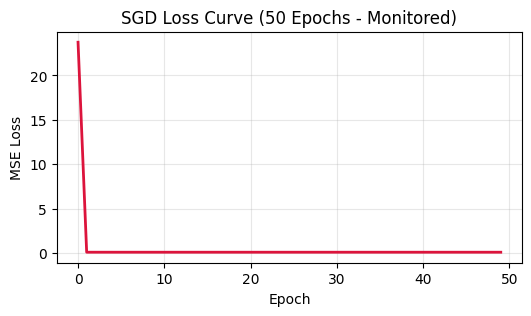

In [49]:
plt.figure(figsize=(6, 3))
plt.plot(sgd_loss_history, color="crimson", lw=2)
plt.title("SGD Loss Curve (50 Epochs - Monitored)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
# ==========================================
# 3. Mini-Batch Gradient Descent from Scratch
# ==========================================
batch_size = 32
np.random.seed(42)
theta_mgd = np.random.randn(2, 1)

mgd_loss_history = []
theta_mgd_history = [theta_mgd.copy()]

lr_mgd = 0.1

for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]

    # Batch by batch loop (step size = 32)
    for i in range(0, m, batch_size):
        xi = X_b_shuffled[i : i + batch_size]
        yi = y_shuffled[i : i + batch_size]

        # Batch ka analytical gradient: (1 / len(xi)) * xi.T * (xi * theta - yi)
        gradients = (1 / len(xi)) * xi.T.dot(xi.dot(theta_mgd) - yi)

        # Weight update
        theta_mgd = theta_mgd - lr_mgd * gradients
        theta_mgd_history.append(theta_mgd.copy())

    # Epoch-level loss monitor
    epoch_loss = (1 / (2 * m)) * np.sum((X_b.dot(theta_mgd) - y) ** 2)
    mgd_loss_history.append(epoch_loss)

print(f"Mini-Batch GD Converged Values:")
print(f"  Bias   (Target ~4) : {theta_mgd[0][0]:.4f}")
print(f"  Weight (Target ~3) : {theta_mgd[1][0]:.4f}")
print(f"Final Loss           : {mgd_loss_history[-1]:.4f}")
print(f"Total Updates        : {len(theta_mgd_history) - 1}")

Mini-Batch GD Converged Values:
  Bias   (Target ~4) : 4.0935
  Weight (Target ~3) : 2.9577
Final Loss           : 0.1219
Total Updates        : 1600


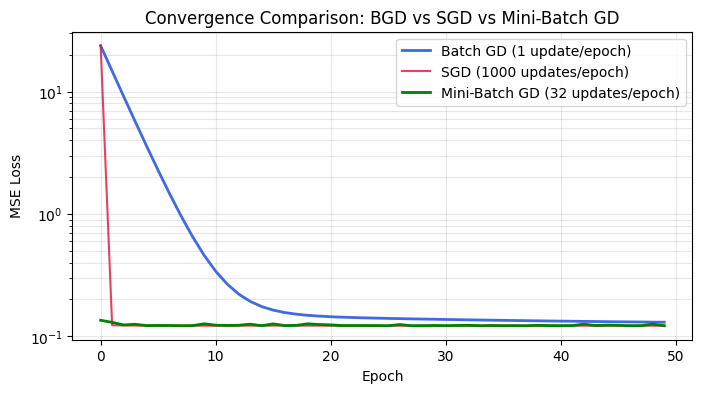

In [51]:
plt.figure(figsize=(8, 4))
plt.plot(bgd_loss_history, label="Batch GD (1 update/epoch)", color="royalblue", lw=2)
plt.plot(sgd_loss_history, label="SGD (1000 updates/epoch)", color="crimson", lw=1.5, alpha=0.8)
plt.plot(mgd_loss_history, label="Mini-Batch GD (32 updates/epoch)", color="green", lw=2)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Convergence Comparison: BGD vs SGD vs Mini-Batch GD")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

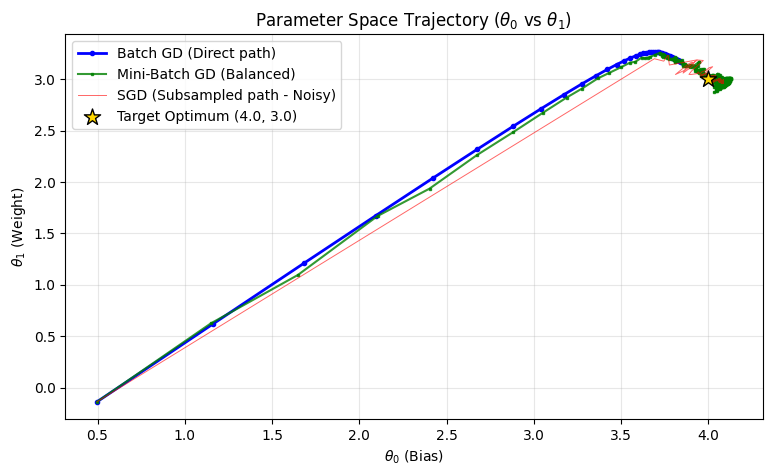

In [53]:

bgd_path = np.array(theta_bgd_history).squeeze()
sgd_path = np.array(theta_sgd_history).squeeze()
mgd_path = np.array(theta_mgd_history).squeeze()

plt.figure(figsize=(9, 5))

# Plotting trajectories
plt.plot(bgd_path[:, 0], bgd_path[:, 1], "b-o", linewidth=2, markersize=3, label="Batch GD (Direct path)")
plt.plot(mgd_path[:, 0], mgd_path[:, 1], "g-s", linewidth=1.5, markersize=2, alpha=0.8, label="Mini-Batch GD (Balanced)")
plt.plot(sgd_path[::20, 0], sgd_path[::20, 1], "r-", linewidth=0.7, alpha=0.6, label="SGD (Subsampled path - Noisy)")

# Target optimum marker (Bias ~4, Weight ~3)
plt.scatter([4.0], [3.0], color="gold", edgecolor="black", s=150, zorder=5, marker="*", label="Target Optimum (4.0, 3.0)")

plt.xlabel(r"$\theta_0$ (Bias)")
plt.ylabel(r"$\theta_1$ (Weight)")
plt.title(r"Parameter Space Trajectory ($\theta_0$ vs $\theta_1$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [54]:
import torch

In [55]:
from torch.utils.data import TensorDataset,DataLoader

In [56]:
X_tensor=torch.tensor(X_b).type(torch.float32)
y_tensor=torch.tensor(y).type(torch.float32)

In [57]:
dataset=TensorDataset(X_tensor,y_tensor)

In [59]:
loader=DataLoader(dataset,batch_size=32,shuffle=True)